데이터 로드 및 전처리를 시작합니다.
데이터 로드 완료, 초기 열: Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')
데이터셋 샘플:
   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN   

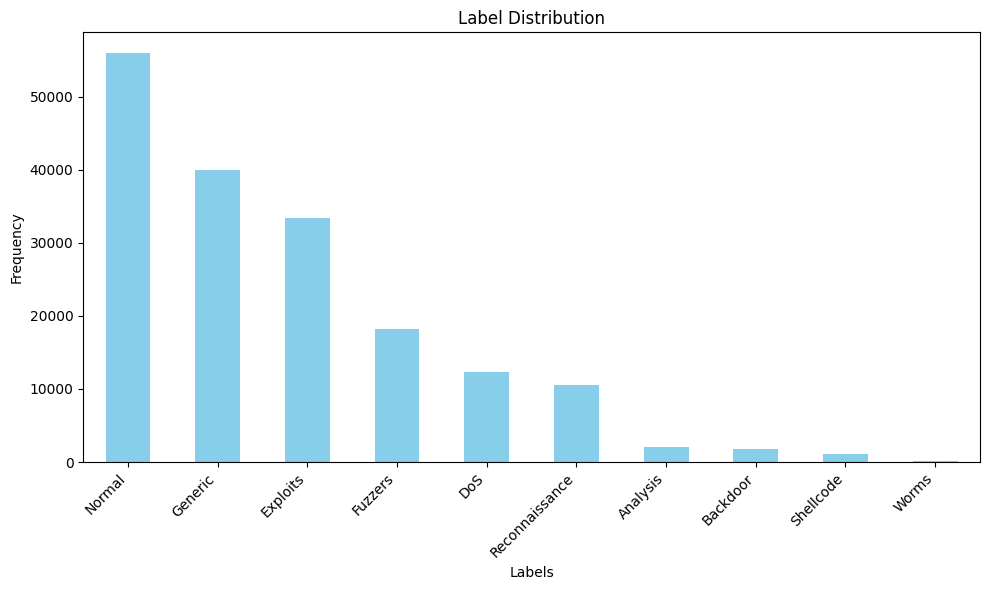

<ipython-input-1-e2a86a849707>:64: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['service'].replace('-', np.nan, inplace=True)


결측값 처리 후 데이터 크기: (81173, 45)
결측값 처리 후 'attack_cat' 열의 레이블 분포:
attack_cat
Generic           39496
Normal            19488
Exploits          16187
DoS                1791
Fuzzers            1731
Reconnaissance     1703
Analysis            564
Worms               114
Backdoor             99
Name: count, dtype: int64


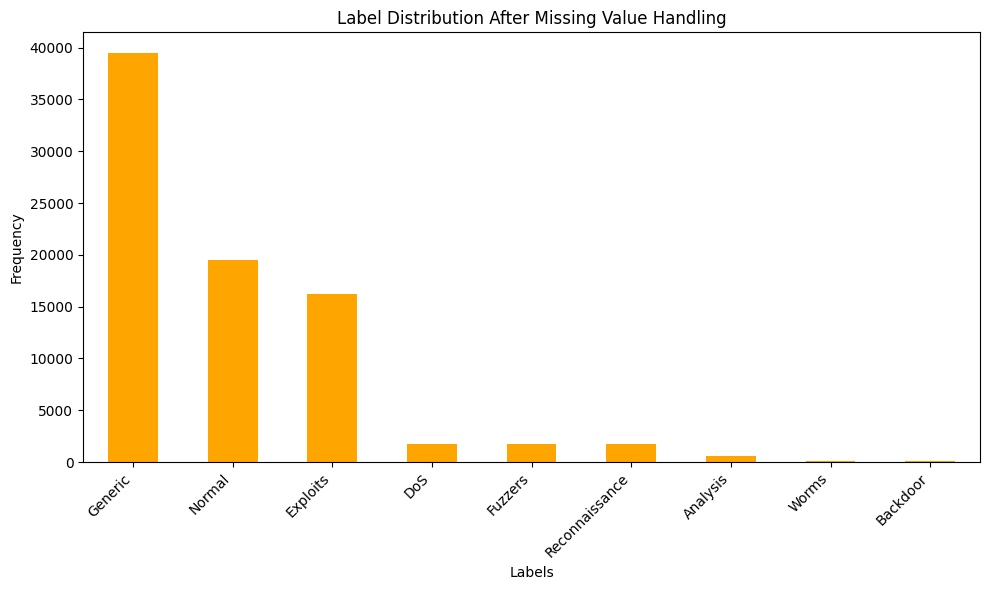

라벨 인코더 저장 완료. 경로: /content/drive/My Drive/result/label_encoder.pkl
범주형 변수 원-핫 인코딩 완료.
이진 변수 처리 완료.
열 정보 저장 완료. 경로: /content/drive/My Drive/result/columns.pkl
스케일러 학습 및 저장 완료. 경로: /content/drive/My Drive/result/scaler.pkl
데이터 로드 및 전처리가 완료되었습니다.
모델 파라미터 설정 완료. 입력 차원: 56, 히든 차원: 128, 클래스 수: 9
K-Fold 교차 검증 및 모델 훈련을 시작합니다.
사용 중인 디바이스: cuda
Stratified K-Fold 설정 완료: 5개의 폴드

Fold 1/5 시작
Train 및 Validation 데이터로더 설정 완료. Train: 64938개, Val: 16235개
모델 초기화 완료. 모델 클래스: AttentionGRU
Optimizer, Scheduler 및 Loss 함수 설정 완료
Epoch 1/10: Train Loss [0.4923] / Val Loss [0.2434], Train Accuracy [89.73%] / Val Accuracy [92.70%]
Epoch 2/10: Train Loss [0.2253] / Val Loss [0.2081], Train Accuracy [92.88%] / Val Accuracy [93.14%]
Epoch 3/10: Train Loss [0.2037] / Val Loss [0.1955], Train Accuracy [93.16%] / Val Accuracy [93.34%]
Epoch 4/10: Train Loss [0.1953] / Val Loss [0.1906], Train Accuracy [93.29%] / Val Accuracy [93.39%]
Epoch 5/10: Train Loss [0.1917] / Val Loss [0.1891], Train Accuracy [93.35%] / Val Acc

In [ ]:
#Train_code #2021245151 정용의

import os
import numpy as np
import pandas as pd
import torch
import joblib
from collections import Counter
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, TensorDataset

train_path = '/content/drive/My Drive/실습/training-set.csv'
scaler_save_path = '/content/drive/My Drive/result/scaler.pkl'
model_save_path = '/content/drive/My Drive/result/train_model.pth'
columns_save_path = '/content/drive/My Drive/result/columns.pkl'
label_encoder_save_path = '/content/drive/My Drive/result/label_encoder.pkl'

def Load_data(file_path, scaler_path=None, columns_path=None):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("데이터 파일이 존재하지 않습니다. 경로를 확인하세요.")
        return None, None, None, None, None, None
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        df.columns = df.columns.str.strip().str.lower()
        print("데이터 로드 완료, 초기 열:", df.columns)
        print("데이터셋 샘플:")
        print(df.head())
    except Exception as e:
        print(f"데이터 정리 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        target_col = 'attack_cat' if 'attack_cat' in df.columns else 'label'
        print(f"'{target_col}' 열의 레이블 분포:")
        initial_label_counts = df[target_col].value_counts()
        print(initial_label_counts)

        plt.figure(figsize=(10, 6))
        initial_label_counts.sort_values(ascending=False).plot(kind='bar', color='skyblue')
        plt.title('Label Distribution')
        plt.xlabel('Labels')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    except KeyError:
        print(f"'{target_col}' 열이 존재하지 않습니다. 데이터를 확인하세요.")
        return None, None, None, None, None, None
    except Exception as e:
        print(f"레이블 처리 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        df['service'].replace('-', np.nan, inplace=True)
        df.dropna(inplace=True)
        print(f"결측값 처리 후 데이터 크기: {df.shape}")
    except Exception as e:
        print(f"결측값 처리 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    post_drop_label_counts = df[target_col].value_counts()
    print(f"결측값 처리 후 '{target_col}' 열의 레이블 분포:")
    print(post_drop_label_counts)

    plt.figure(figsize=(10, 6))
    sorted_post_counts = post_drop_label_counts.sort_values(ascending=False)
    sorted_post_counts.plot(kind='bar', color='orange')
    plt.title('Label Distribution After Missing Value Handling')
    plt.xlabel('Labels')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    try:
        if 'id' in df.columns:
            ids = df['id'].values
            df.drop(columns=['id'], inplace=True)
        else:
            ids = np.arange(len(df))
    except Exception as e:
        print(f"ID 처리 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        le = LabelEncoder()
        df[target_col] = le.fit_transform(df[target_col])
        joblib.dump(le, label_encoder_save_path)
        print(f"라벨 인코더 저장 완료. 경로: {label_encoder_save_path}")

        labels = df[target_col].values
        df.drop(columns=[target_col], inplace=True)
    except Exception as e:
        print(f"라벨 인코딩 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        categorical_columns = ['proto', 'service', 'state']
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
        print("범주형 변수 원-핫 인코딩 완료.")
    except KeyError as e:
        print(f"범주형 변수 컬럼이 누락되었습니다: {e}")
        return None, None, None, None, None, None
    except Exception as e:
        print(f"원-핫 인코딩 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        binary_columns = ['is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']
        for col in binary_columns:
            if col in df.columns:
                df[col] = df[col].apply(lambda x: 1 if x == '1' else 0)
            else:
                print(f"이진 변수 '{col}'가 누락되었습니다.")
        print("이진 변수 처리 완료.")
    except Exception as e:
        print(f"이진 변수 처리 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    try:
        if columns_path:
            expected_columns = joblib.load(columns_path)
            df = df.reindex(columns=expected_columns, fill_value=0)
            print(f"열 정렬 완료. 기준 열: {columns_path}")
        else:
            joblib.dump(df.columns.tolist(), columns_save_path)
            print(f"열 정보 저장 완료. 경로: {columns_save_path}")

        if scaler_path:
            scaler = joblib.load(scaler_path)
            features = scaler.transform(df.values)
            print(f"스케일러 로드 완료. 경로: {scaler_path}")
        else:
            scaler = StandardScaler()
            features = scaler.fit_transform(df.values)
            joblib.dump(scaler, scaler_save_path)
            print(f"스케일러 학습 및 저장 완료. 경로: {scaler_save_path}")
    except Exception as e:
        print(f"스케일링 및 열 정렬 중 오류가 발생했습니다: {e}")
        return None, None, None, None, None, None

    return features, labels, ids, scaler, le, df.columns.tolist()

class AttentionGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1):
        super(AttentionGRU, self).__init__()
        try:
            self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
            self.attn = nn.Linear(hidden_dim, 1)
            self.fc = nn.Linear(hidden_dim, num_classes)
        except Exception as e:
            print(f"모델 초기화 중 오류가 발생했습니다: {e}")

    def forward(self, x):
        try:
            x, _ = self.gru(x)
            attn_weights = torch.softmax(self.attn(x), dim=1)
            x = torch.sum(attn_weights * x, dim=1)
            return self.fc(x)
        except Exception as e:
            print(f"모델 순전파 중 오류가 발생했습니다: {e}")
            return None

def Stratified_kfold(model_class, X, y, input_dim, hidden_dim, num_classes, folds=5, num_epochs=10, batch_size=256):
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"사용 중인 디바이스: {device}")
    except Exception as e:
        print(f"디바이스 설정 중 오류가 발생했습니다: {e}")
        return None, None

    try:
        kfold = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
        print(f"Stratified K-Fold 설정 완료: {folds}개의 폴드")
    except Exception as e:
        print(f"Stratified K-Fold 초기화 중 오류가 발생했습니다: {e}")
        return None, None

    val_data = None
    best_model_state = None
    best_val_accuracy = 0.0
    best_fold_history = None

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"\nFold {fold + 1}/{folds} 시작")
        try:
            train_loader = DataLoader(
                TensorDataset(
                    torch.tensor(X[train_idx], dtype=torch.float32).unsqueeze(1),
                    torch.tensor(y[train_idx], dtype=torch.long)
                ),
                batch_size=batch_size,
                shuffle=True
            )
            val_loader = DataLoader(
                TensorDataset(
                    torch.tensor(X[val_idx], dtype=torch.float32).unsqueeze(1),
                    torch.tensor(y[val_idx], dtype=torch.long)
                ),
                batch_size=batch_size,
                shuffle=False
            )
            print(f"Train 및 Validation 데이터로더 설정 완료. Train: {len(train_idx)}개, Val: {len(val_idx)}개")
        except Exception as e:
            print(f"데이터 로더 설정 중 오류가 발생했습니다: {e}")
            return None, None

        try:
            model = model_class(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes)
            model.to(device)
            print(f"모델 초기화 완료. 모델 클래스: {model_class.__name__}")
        except Exception as e:
            print(f"모델 초기화 중 오류가 발생했습니다: {e}")
            return None, None

        try:
            optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
            scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
            criterion = nn.CrossEntropyLoss()
            print("Optimizer, Scheduler 및 Loss 함수 설정 완료")
        except Exception as e:
            print(f"Optimizer 또는 Loss 함수 설정 중 오류가 발생했습니다: {e}")
            return None, None

        fold_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

        for epoch in range(num_epochs):
            try:
                model.train()
                total_loss, correct, total = 0.0, 0, 0
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item() * inputs.size(0)
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()

                train_loss = total_loss / total
                train_accuracy = correct / total * 100
            except RuntimeError as e:
                print(f"model.train에서 오류 발생 : {e}")
                return

            try:
                model.eval()
                val_loss = 0.0
                val_correct, val_total = 0, 0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item() * inputs.size(0)
                        _, predicted = outputs.max(1)
                        val_total += labels.size(0)
                        val_correct += predicted.eq(labels).sum().item()

                val_loss /= val_total
                val_accuracy = val_correct / val_total * 100
                fold_history['loss'].append(train_loss)
                fold_history['val_loss'].append(val_loss)
                fold_history['accuracy'].append(train_accuracy)
                fold_history['val_accuracy'].append(val_accuracy)

                print(f"Epoch {epoch + 1}/{num_epochs}: Train Loss [{train_loss:.4f}] / Val Loss [{val_loss:.4f}], "
                  f"Train Accuracy [{train_accuracy:.2f}%] / Val Accuracy [{val_accuracy:.2f}%]")
            except Exception as e:
                print(f"검증 과정 중 오류가 발생했습니다 (Epoch {epoch + 1}): {e}")
                return None, None

            try:
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_model_state = model.state_dict()
                    best_fold_history = fold_history
            except Exception as e:
                print(f"최고 성능 업데이트 중 오류가 발생했습니다: {e}")
                return None, None

            try:
                scheduler.step()
            except Exception as e:
                print(f"Scheduler 업데이트 중 오류가 발생했습니다: {e}")
                return None, None

        val_data = (X[val_idx], y[val_idx])

    try:
        torch.save(best_model_state, model_save_path)
        print(f"Best model saved to {model_save_path} with Validation Accuracy: {best_val_accuracy:.2f}%")
    except Exception as e:
        print(f"모델 저장 중 오류가 발생했습니다: {e}")
        return None, None

    return best_fold_history, val_data

def plot_training(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train/Validation Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Train/Validation Accuracy')
    plt.legend()
    plt.show()

def plot_classwise_accuracy(y_true_train, y_pred_train, y_true_val, y_pred_val, label_encoder):
    train_classwise_accuracy = []
    val_classwise_accuracy = []
    class_frequencies = []

    class_names = label_encoder.inverse_transform(np.arange(len(np.unique(y_true_train))))

    for cls in np.unique(y_true_train):

        train_indices = y_true_train == cls
        train_accuracy = np.mean(y_pred_train[train_indices] == y_true_train[train_indices])
        train_classwise_accuracy.append(train_accuracy)

        val_indices = y_true_val == cls
        val_accuracy = np.mean(y_pred_val[val_indices] == y_true_val[val_indices])
        val_classwise_accuracy.append(val_accuracy)

        class_frequency = np.sum(y_true_train == cls)
        class_frequencies.append(class_frequency)

    sorted_indices = np.argsort(class_frequencies)[::-1]
    class_names = np.array(class_names)[sorted_indices]
    train_classwise_accuracy = np.array(train_classwise_accuracy)[sorted_indices]
    val_classwise_accuracy = np.array(val_classwise_accuracy)[sorted_indices]

    x = np.arange(len(class_names))
    bar_width = 0.35

    plt.figure(figsize=(12, 6))
    bars_train = plt.bar(x - bar_width / 2, train_classwise_accuracy, bar_width, label="Train Accuracy", color="blue", alpha=0.7)
    bars_val = plt.bar(x + bar_width / 2, val_classwise_accuracy, bar_width, label="Validation Accuracy", color="orange", alpha=0.7)

    for bar in bars_train:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height() * 100:.1f}%",
                 ha='center', va='bottom', fontsize=8, color="black")
    for bar in bars_val:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height() * 100:.1f}%",
                 ha='center', va='bottom', fontsize=8, color="black")

    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x * 100)}"))
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.2))

    plt.xlabel("Classes (sorted by frequency)")
    plt.ylabel("Accuracy (%)")
    plt.title("Classwise Train vs Validation Accuracy (Sorted by Frequency)")
    plt.xticks(ticks=x, labels=class_names, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

def main_train():
    try:
        print("데이터 로드 및 전처리를 시작합니다.")
        X_train, y_train, ids, scaler, le, columns = Load_data(train_path)
        if X_train is None or y_train is None:
            raise ValueError("데이터 로드 실패. Load_data 함수의 반환값을 확인하세요.")
        print("데이터 로드 및 전처리가 완료되었습니다.")
    except Exception as e:
        print(f"데이터 로드 및 전처리 중 오류가 발생했습니다: {e}")
        return

    try:
        input_dim = X_train.shape[1]
        hidden_dim = 128
        num_classes = len(np.unique(y_train))
        print(f"모델 파라미터 설정 완료. 입력 차원: {input_dim}, 히든 차원: {hidden_dim}, 클래스 수: {num_classes}")
    except Exception as e:
        print(f"모델 파라미터 설정 중 오류가 발생했습니다: {e}")
        return

    try:
        print("K-Fold 교차 검증 및 모델 훈련을 시작합니다.")
        best_fold_history, val_data = Stratified_kfold(
            AttentionGRU,
            X_train,
            y_train,
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_classes=num_classes,
            folds=5,
            num_epochs=10,
            batch_size=256
        )
        if val_data is None:
            raise ValueError("교차 검증 중 데이터 분리 실패. kfold 함수의 반환값을 확인하세요.")
        print("K-Fold 교차 검증 및 모델 훈련이 완료되었습니다.")
    except Exception as e:
        print(f"교차 검증 및 모델 훈련 중 오류가 발생했습니다: {e}")
        return

    try:
        X_val, y_val = val_data
        print(f"Validation 데이터 분리 완료. Validation 데이터 크기: {X_val.shape[0]}")
    except Exception as e:
        print(f"Validation 데이터 분리 중 오류가 발생했습니다: {e}")
        return

    try:
        print("모델 생성 및 가중치 로드를 시작합니다.")
        model = AttentionGRU(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes)
        model.load_state_dict(torch.load(model_save_path, weights_only=True))
        model.eval()
        print("모델 생성 및 가중치 로드가 완료되었습니다.")
    except FileNotFoundError:
        print(f"모델 가중치 파일이 존재하지 않습니다. 경로를 확인하세요: {model_save_path}")
        return
    except Exception as e:
        print(f"모델 생성 및 가중치 로드 중 오류가 발생했습니다: {e}")
        return

    y_pred_train = model(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)).argmax(1).numpy()
    y_pred_val = model(torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)).argmax(1).numpy()
    plot_training(best_fold_history)
    plot_classwise_accuracy(y_train, y_pred_train, y_val, y_pred_val, le)

if __name__ == "__main__":
    main_train()